In [1]:
!pip install pyspark

In [2]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, isnan, count, lit, expr, row_number
from pyspark.sql.window import Window

In [3]:
spark = SparkSession.builder.getOrCreate()

In [4]:
mental_illness_prevalence = spark.read.csv('1-mental-illnesses-prevalence.csv', header=True, inferSchema=True)
burden_disease = spark.read.csv('2-burden-disease-from-mental-illness.csv', header=True, inferSchema=True)
anxiety_disorders_treatment = spark.read.csv('5-anxiety-disorders-treatment-gap.csv', header=True, inferSchema=True)
depressive_symptoms = spark.read.csv('6-depressive-symptoms-across-us-population.csv', header=True, inferSchema=True)

In [5]:
print('dataframe mental_illness_prevalence:')
print(mental_illness_prevalence.printSchema())
print(mental_illness_prevalence.show(n=5, truncate=False))

print('dataframe burden_disease:')
print(burden_disease.printSchema())
print(burden_disease.show(n=5, truncate=False))

print('dataframe anxiety_disorders_treatment:')
print(anxiety_disorders_treatment.printSchema())
print(anxiety_disorders_treatment.show(n=5, truncate=False))

print('dataframe depressive_symptoms:')
print(depressive_symptoms.printSchema())
print(depressive_symptoms.show(n=5, truncate=False))

dataframe mental_illness_prevalence:
root
 |-- Entity: string (nullable = true)
 |-- Code: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized: double (nullable = true)
 |-- Depressive disorders (share of population) - Sex: Both - Age: Age-standardized: double (nullable = true)
 |-- Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized: double (nullable = true)
 |-- Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized: double (nullable = true)
 |-- Eating disorders (share of population) - Sex: Both - Age: Age-standardized: double (nullable = true)

None
+-----------+----+----+---------------------------------------------------------------------------------+------------------------------------------------------------------------------+---------------------------------------------------------------------------+--------------------------------------

**Limpeza e Preparação dos Dados**

In [6]:
# Renomear titulos das colunas para nomes mais curtos
mental_illness_prevalence = mental_illness_prevalence.withColumnRenamed("Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized", "Schizophrenia(%)") \
                                                      .withColumnRenamed("Depressive disorders (share of population) - Sex: Both - Age: Age-standardized", "Depression(%)") \
                                                      .withColumnRenamed("Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized", "Anxiety(%)") \
                                                      .withColumnRenamed("Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized", "Bipolar(%)") \
                                                      .withColumnRenamed("Eating disorders (share of population) - Sex: Both - Age: Age-standardized", "EatingDisorders(%)")
mental_illness_prevalence.show(5)

+-----------+----+----+----------------+-------------+----------+----------+------------------+
|     Entity|Code|Year|Schizophrenia(%)|Depression(%)|Anxiety(%)|Bipolar(%)|EatingDisorders(%)|
+-----------+----+----+----------------+-------------+----------+----------+------------------+
|Afghanistan| AFG|1990|      0.22320578|     4.996118|  4.713314|0.70302314|        0.12770003|
|Afghanistan| AFG|1991|      0.22245377|    4.9892898|    4.7021| 0.7020688|       0.123255946|
|Afghanistan| AFG|1992|      0.22175121|    4.9813457|  4.683743|  0.700792|        0.11884415|
|Afghanistan| AFG|1993|      0.22098725|    4.9769583| 4.6735487|0.70008695|        0.11508888|
|Afghanistan| AFG|1994|      0.22018303|     4.977782|   4.67081| 0.6998978|        0.11181468|
+-----------+----+----+----------------+-------------+----------+----------+------------------+
only showing top 5 rows



In [7]:
# Renomear titulos das colunas para nomes mais curtos
burden_disease = burden_disease.withColumnRenamed("DALYs (rate) - Sex: Both - Age: Age-standardized - Cause: Depressive disorders", "Depression_DALY") \
                                .withColumnRenamed("DALYs (rate) - Sex: Both - Age: Age-standardized - Cause: Schizophrenia", "Schizophrenia_DALY") \
                                .withColumnRenamed("DALYs (rate) - Sex: Both - Age: Age-standardized - Cause: Bipolar disorder", "Bipolar_DALY") \
                                .withColumnRenamed("DALYs (rate) - Sex: Both - Age: Age-standardized - Cause: Eating disorders", "EatingDisorders_DALY") \
                                .withColumnRenamed("DALYs (rate) - Sex: Both - Age: Age-standardized - Cause: Anxiety disorders", "Anxiety_DALY")
burden_disease.show(5)

+-----------+----+----+---------------+------------------+------------+--------------------+------------+
|     Entity|Code|Year|Depression_DALY|Schizophrenia_DALY|Bipolar_DALY|EatingDisorders_DALY|Anxiety_DALY|
+-----------+----+----+---------------+------------------+------------+--------------------+------------+
|Afghanistan| AFG|1990|      895.22565|         138.24825|   147.64412|           26.471115|      440.33|
|Afghanistan| AFG|1991|      893.88434|         137.76122|   147.56696|           25.548681|   439.47202|
|Afghanistan| AFG|1992|      892.34973|          137.0803|   147.13086|           24.637949|   437.60718|
|Afghanistan| AFG|1993|      891.51587|         136.48602|   146.78812|           23.863169|   436.69104|
|Afghanistan| AFG|1994|       891.3916|         136.18323|   146.58481|           23.189074|     436.768|
+-----------+----+----+---------------+------------------+------------+--------------------+------------+
only showing top 5 rows



In [8]:
# Renomear titulos das colunas para nomes mais curtos
anxiety_disorders_treatment = anxiety_disorders_treatment.withColumnRenamed("Potentially adequate treatment, conditional", "AdequateTreatment") \
         .withColumnRenamed("Other treatments, conditional", "OtherTreatment") \
         .withColumnRenamed("Untreated, conditional", "Untreated")

anxiety_disorders_treatment.show(5)

+--------------------+----+----+-----------------+--------------+---------+
|              Entity|Code|Year|AdequateTreatment|OtherTreatment|Untreated|
+--------------------+----+----+-----------------+--------------+---------+
|           Argentina| ARG|2015|             12.0|          18.0|     70.0|
|Beijing/Shanghai,...|NULL|2005|              8.8|           8.5|     82.7|
|             Belgium| BEL|2002|             11.2|          24.5|     64.3|
|            Bulgaria| BGR|2006|              7.3|          14.3|     78.4|
|            Colombia| COL|2012|              3.2|          10.0|     86.8|
+--------------------+----+----+-----------------+--------------+---------+
only showing top 5 rows



In [9]:
# Renomear titulos das colunas para nomes mais curtos
depressive_symptoms = depressive_symptoms.withColumnRenamed("Nearly every day", "Freq_NearlyEveryDay") \
         .withColumnRenamed("More than half the days", "Freq_MoreThanHalf") \
         .withColumnRenamed("Several days", "Freq_SeveralDays") \
         .withColumnRenamed("Not at all", "Freq_NotAtAll")

depressive_symptoms.show(5)

+--------------------+----+----+-------------------+-----------------+----------------+-------------+
|              Entity|Code|Year|Freq_NearlyEveryDay|Freq_MoreThanHalf|Freq_SeveralDays|Freq_NotAtAll|
+--------------------+----+----+-------------------+-----------------+----------------+-------------+
|     Appetite change|NULL|2014|                4.6|              5.1|            15.5|         74.8|
|Average across sy...|NULL|2014|                4.4|              4.3|            15.0|         76.3|
|      Depressed mood|NULL|2014|                3.6|              3.9|            16.8|         75.7|
|Difficulty concen...|NULL|2014|                3.5|              3.6|            10.9|         82.1|
|    Loss of interest|NULL|2014|                4.4|              5.4|            16.3|         73.8|
+--------------------+----+----+-------------------+-----------------+----------------+-------------+
only showing top 5 rows



In [10]:
# verificar valores nulos

def verificar_nulos(df, nome_tabela):
    print(f"\n🔎 Tabela: {nome_tabela}")
    df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

In [11]:
verificar_nulos(mental_illness_prevalence, 'mental_illness_prevalence')
verificar_nulos(burden_disease, 'burden_disease')
verificar_nulos(anxiety_disorders_treatment, 'anxiety_disorders_treatment')
verificar_nulos(depressive_symptoms, 'depressive_symptoms')


🔎 Tabela: mental_illness_prevalence
+------+----+----+----------------+-------------+----------+----------+------------------+
|Entity|Code|Year|Schizophrenia(%)|Depression(%)|Anxiety(%)|Bipolar(%)|EatingDisorders(%)|
+------+----+----+----------------+-------------+----------+----------+------------------+
|     0| 270|   0|               0|            0|         0|         0|                 0|
+------+----+----+----------------+-------------+----------+----------+------------------+


🔎 Tabela: burden_disease
+------+----+----+---------------+------------------+------------+--------------------+------------+
|Entity|Code|Year|Depression_DALY|Schizophrenia_DALY|Bipolar_DALY|EatingDisorders_DALY|Anxiety_DALY|
+------+----+----+---------------+------------------+------------+--------------------+------------+
|     0| 690|   0|              0|                 0|           0|                   0|           0|
+------+----+----+---------------+------------------+------------+-----------

In [12]:
# drop coluna "code" da df depressive_symptoms
depressive_symptoms = depressive_symptoms.drop("Code")

depressive_symptoms.printSchema()

root
 |-- Entity: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Freq_NearlyEveryDay: double (nullable = true)
 |-- Freq_MoreThanHalf: double (nullable = true)
 |-- Freq_SeveralDays: double (nullable = true)
 |-- Freq_NotAtAll: double (nullable = true)



In [13]:
# adicionar uma coluna no df "anxiety_disorders_treatment" onde mostrará o nivel de alerta para pessoas não tratadas

anxiety_disorders_treatment = anxiety_disorders_treatment.withColumn(
    "Alerta",
    when(col("Untreated") >= 70, "Alta")
    .when(col("Untreated") >= 40, "Moderada")
    .otherwise("Baixa")
)

anxiety_disorders_treatment.show(5)

+--------------------+----+----+-----------------+--------------+---------+--------+
|              Entity|Code|Year|AdequateTreatment|OtherTreatment|Untreated|  Alerta|
+--------------------+----+----+-----------------+--------------+---------+--------+
|           Argentina| ARG|2015|             12.0|          18.0|     70.0|    Alta|
|Beijing/Shanghai,...|NULL|2005|              8.8|           8.5|     82.7|    Alta|
|             Belgium| BEL|2002|             11.2|          24.5|     64.3|Moderada|
|            Bulgaria| BGR|2006|              7.3|          14.3|     78.4|    Alta|
|            Colombia| COL|2012|              3.2|          10.0|     86.8|    Alta|
+--------------------+----+----+-----------------+--------------+---------+--------+
only showing top 5 rows



In [14]:
# adicionar uma coluna "treated" no df "anxiety_disorders_treatment" que somará os dois tipos de tratamento e vai dar o total de pessoas tratadas

anxiety_disorders_treatment = anxiety_disorders_treatment.withColumn(
    "Treated",
    col("AdequateTreatment") + col("OtherTreatment")
)

anxiety_disorders_treatment.show(5)

+--------------------+----+----+-----------------+--------------+---------+--------+-------+
|              Entity|Code|Year|AdequateTreatment|OtherTreatment|Untreated|  Alerta|Treated|
+--------------------+----+----+-----------------+--------------+---------+--------+-------+
|           Argentina| ARG|2015|             12.0|          18.0|     70.0|    Alta|   30.0|
|Beijing/Shanghai,...|NULL|2005|              8.8|           8.5|     82.7|    Alta|   17.3|
|             Belgium| BEL|2002|             11.2|          24.5|     64.3|Moderada|   35.7|
|            Bulgaria| BGR|2006|              7.3|          14.3|     78.4|    Alta|   21.6|
|            Colombia| COL|2012|              3.2|          10.0|     86.8|    Alta|   13.2|
+--------------------+----+----+-----------------+--------------+---------+--------+-------+
only showing top 5 rows



In [15]:
# adicionar uma coluna "Sintomas" no df "depressive_symptoms" que somará a frequencia que cada sintoma aparece e vai dar o total
depressive_symptoms = depressive_symptoms.withColumn("Sintomas",
                   col("Freq_NearlyEveryDay") + col("Freq_MoreThanHalf") + col("Freq_SeveralDays"))

depressive_symptoms.show(5)

+--------------------+----+-------------------+-----------------+----------------+-------------+--------+
|              Entity|Year|Freq_NearlyEveryDay|Freq_MoreThanHalf|Freq_SeveralDays|Freq_NotAtAll|Sintomas|
+--------------------+----+-------------------+-----------------+----------------+-------------+--------+
|     Appetite change|2014|                4.6|              5.1|            15.5|         74.8|    25.2|
|Average across sy...|2014|                4.4|              4.3|            15.0|         76.3|    23.7|
|      Depressed mood|2014|                3.6|              3.9|            16.8|         75.7|    24.3|
|Difficulty concen...|2014|                3.5|              3.6|            10.9|         82.1|    18.0|
|    Loss of interest|2014|                4.4|              5.4|            16.3|         73.8|    26.1|
+--------------------+----+-------------------+-----------------+----------------+-------------+--------+
only showing top 5 rows



**Análise Exploratória**

In [16]:
from functools import reduce
from pyspark.sql import DataFrame

**1. Top 10 países com maior prevalência de transtornos mentais no ano de 2019**

In [17]:
# Filtrar o ano para 2019
mental_illness_prevalence_2019 = mental_illness_prevalence.filter(col("Year") == 2019)

In [18]:
# Função para gerar ranking por transtorno
def top10(df, coluna, nome_coluna):
    window = Window.orderBy(col(coluna).desc())
    return df.select("Entity", col(coluna)) \
             .withColumn("Rank", row_number().over(window)) \
             .filter(col("Rank") <= 10) \
             .withColumnRenamed("Entity", nome_coluna) \
             .select("Rank", nome_coluna)

# Gerar rankings
top_esquizofrenia = top10(mental_illness_prevalence_2019, "Schizophrenia(%)", "Schizophrenia")
top_depressao = top10(mental_illness_prevalence_2019, "Depression(%)", "Depression")
top_ansiedade = top10(mental_illness_prevalence_2019, "Anxiety(%)", "Anxiety")
top_bipolar = top10(mental_illness_prevalence_2019, "Bipolar(%)", "Bipolar")
top_alimentar = top10(mental_illness_prevalence_2019, "EatingDisorders(%)", "EatingDisorders")

In [19]:
# Unir os DataFrames pelo Rank
dfs = [top_esquizofrenia, top_depressao, top_ansiedade, top_bipolar, top_alimentar]
Ranking_horizontal = reduce(lambda df1, df2: df1.join(df2, "Rank"), dfs)

# Exibir tabela final
Ranking_horizontal.orderBy("Rank").show(truncate=False)

+----+---------------------+------------------------+-----------+--------------+---------------+
|Rank|Schizophrenia        |Depression              |Anxiety    |Bipolar       |EatingDisorders|
+----+---------------------+------------------------+-----------+--------------+---------------+
|1   |United States        |Uganda                  |Portugal   |New Zealand   |Australia      |
|2   |Australia            |Palestine               |Brazil     |Australia     |Monaco         |
|3   |New Zealand          |Central African Republic|Iran       |Brazil        |New Zealand    |
|4   |Greenland            |Greenland               |New Zealand|United Kingdom|Spain          |
|5   |Netherlands          |Angola                  |Ireland    |Paraguay      |Luxembourg     |
|6   |Ireland              |Equatorial Guinea       |Switzerland|Israel        |Austria        |
|7   |America (IHME GBD)   |Gabon                   |Netherlands|Argentina     |Italy          |
|8   |Guam                 |Co

**2. Observar se há crescimento ou redução ao longo dos anos da prevalência de transtornos mentais**

In [20]:
# Agrupar por ano e calcular a média de cada transtorno

mental_illness_prevalence_anos = mental_illness_prevalence.groupBy("Year").agg(
    {"Schizophrenia(%)": "avg",
     "Depression(%)": "avg",
     "Anxiety(%)": "avg",
     "Bipolar(%)": "avg",
     "EatingDisorders(%)": "avg"}
).orderBy("Year")

In [21]:
# Coletar os dados
mental_illness_prevalence_dados = mental_illness_prevalence_anos.collect()

# Listas para o eixo X (anos) e Y (valores médios por transtorno)
anos = [row["Year"] for row in mental_illness_prevalence_dados]
schizo = [row["avg(Schizophrenia(%))"] for row in mental_illness_prevalence_dados]
depr = [row["avg(Depression(%))"] for row in mental_illness_prevalence_dados]
anx = [row["avg(Anxiety(%))"] for row in mental_illness_prevalence_dados]
bip = [row["avg(Bipolar(%))"] for row in mental_illness_prevalence_dados]
eat = [row["avg(EatingDisorders(%))"] for row in mental_illness_prevalence_dados]

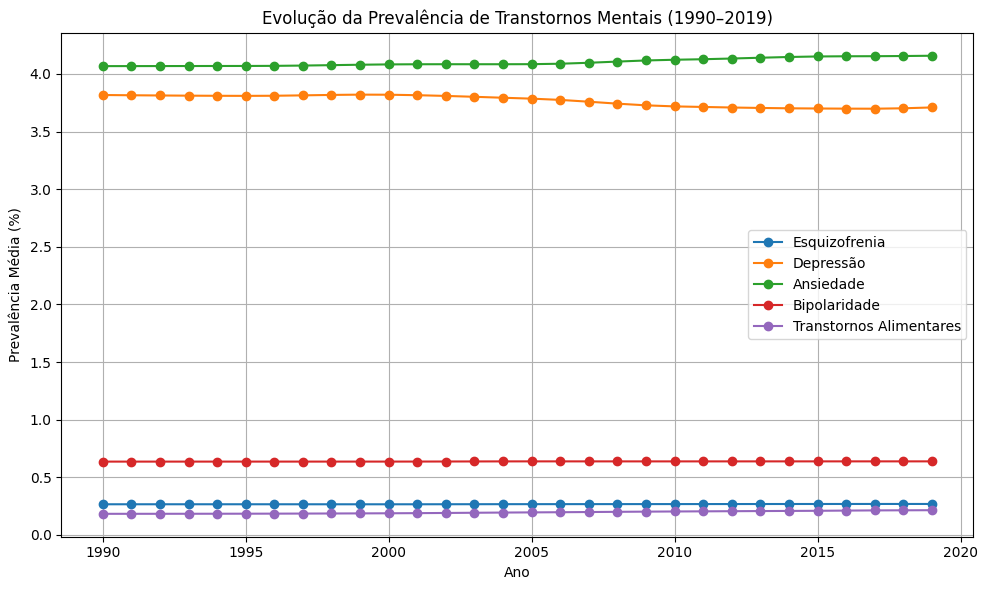

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(anos, schizo, label="Esquizofrenia", marker='o')
plt.plot(anos, depr, label="Depressão", marker='o')
plt.plot(anos, anx, label="Ansiedade", marker='o')
plt.plot(anos, bip, label="Bipolaridade", marker='o')
plt.plot(anos, eat, label="Transtornos Alimentares", marker='o')

plt.title("Evolução da Prevalência de Transtornos Mentais (1990–2019)")
plt.xlabel("Ano")
plt.ylabel("Prevalência Média (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**3. Ver quais países tem maior impacto negativo da doença na qualidade de vida da populção**

DALY (Disability-Adjusted Life Years) é uma métrica usada pela OMS para medir o peso de uma doença na população, representa os anos de vida perdidos por morte precoce + anos vividos com incapacidade.

In [23]:
from pyspark.sql.functions import col, sum as spark_sum

# Criar coluna com soma dos DALYs
burden_disease_daly = burden_disease.withColumn(
    "Total_DALY",
    col("Depression_DALY") +
    col("Schizophrenia_DALY") +
    col("Bipolar_DALY") +
    col("EatingDisorders_DALY") +
    col("Anxiety_DALY")
)

In [24]:
# Agrupar por país e calcular média
burden_disease_daly_media = burden_disease_daly.groupBy("Entity").agg({"Total_DALY": "avg"})
burden_disease_daly_media = burden_disease_daly_media.withColumnRenamed("avg(Total_DALY)", "Media_Total_DALY")

In [25]:
# Ordenar e converter para pandas
burden_diseas_top_impacto = burden_disease_daly_media.orderBy("Media_Total_DALY", ascending=False).limit(10).toPandas()

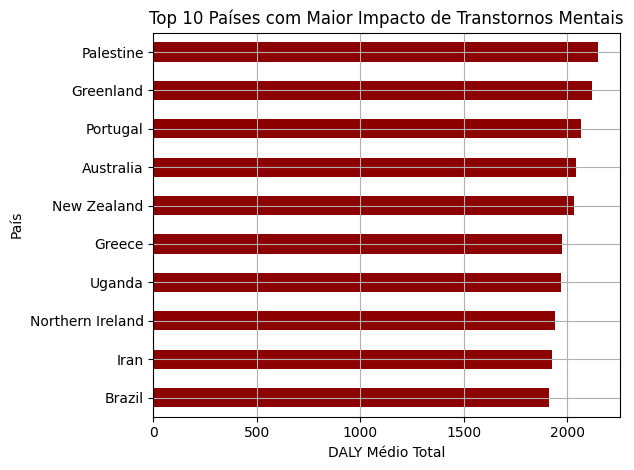

In [26]:
burden_diseas_top_impacto.plot.barh(x="Entity", y="Media_Total_DALY", color="darkred", legend=False)
plt.title("Top 10 Países com Maior Impacto de Transtornos Mentais")
plt.xlabel("DALY Médio Total")
plt.ylabel("País")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

**4.Ver a correlação entre a prevalência de transtornos mentais e o impacto da doença mental (DALYs)**

In [27]:
# Soma das prevalências
mental_illness_prevalence_total = mental_illness_prevalence.withColumn(
    "Prevalencia_Total",
    col("Schizophrenia(%)") +
    col("Depression(%)") +
    col("Anxiety(%)") +
    col("Bipolar(%)") +
    col("EatingDisorders(%)")
)

In [28]:
df_join = mental_illness_prevalence_total.join(burden_disease_daly, "Entity", "inner")

In [29]:
# Converter para pandas para visualização
dados = df_join.select("Prevalencia_Total", "Total_DALY").toPandas()

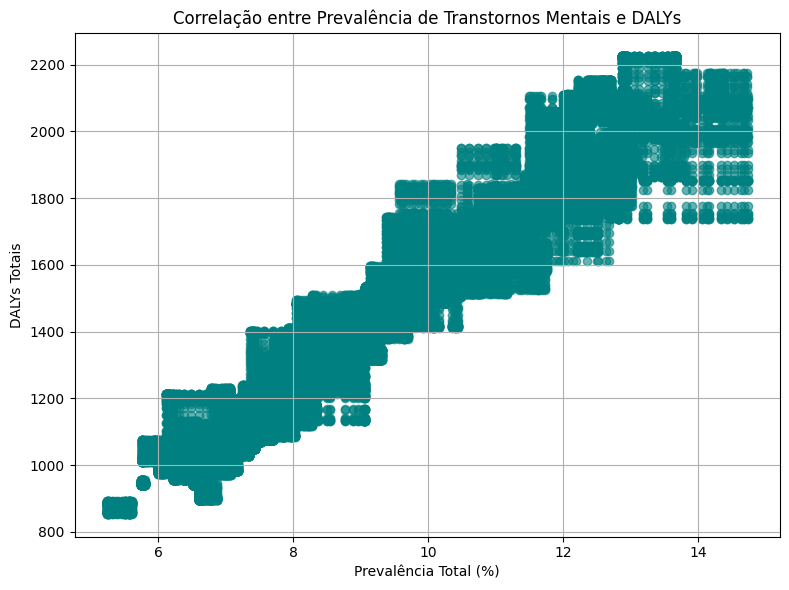

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(dados["Prevalencia_Total"], dados["Total_DALY"], alpha=0.6, color="teal")
plt.title("Correlação entre Prevalência de Transtornos Mentais e DALYs")
plt.xlabel("Prevalência Total (%)")
plt.ylabel("DALYs Totais")
plt.grid(True)
plt.tight_layout()
plt.show()

**5.	Identificar países onde o impacto da doença mental (DALYs) é desproporcional à prevalência**


In [31]:
# Calcular a razão DALY/prevalencia

df_join = df_join.withColumn("Razao_Impacto", col("Total_DALY") / col("Prevalencia_Total"))

In [32]:
df_agrupado = df_join.groupBy("Entity").avg("Razao_Impacto")
df_agrupado = df_agrupado.withColumnRenamed("avg(Razao_Impacto)", "Media_Razao_Impacto")

In [33]:
top_impacto = df_agrupado.orderBy(col("Media_Razao_Impacto").desc()).limit(10).toPandas()

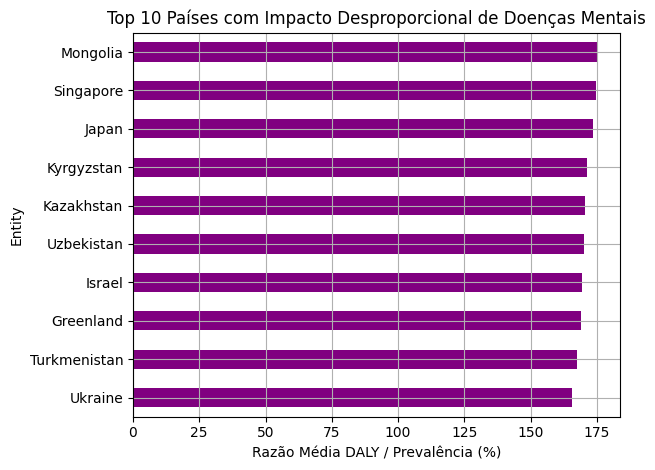

In [34]:
import matplotlib.pyplot as plt

top_impacto.plot.barh(x="Entity", y="Media_Razao_Impacto", color="purple", legend=False)
plt.title("Top 10 Países com Impacto Desproporcional de Doenças Mentais")
plt.xlabel("Razão Média DALY / Prevalência (%)")
plt.ylabel("Entity")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


**6.	Identificar quais sintomas depressivos são mais persistentes e quais são mais esporádicos na população dos Estados Unidos**

In [35]:
df_sintomas = depressive_symptoms.filter(~col("Entity").contains("Average"))

In [36]:
df_sintomas_plot = df_sintomas.select(
    col("Entity"),
    col("Freq_NearlyEveryDay"),
    col("Freq_MoreThanHalf"),
    col("Freq_SeveralDays"),
    col("Freq_NotAtAll")
).toPandas()

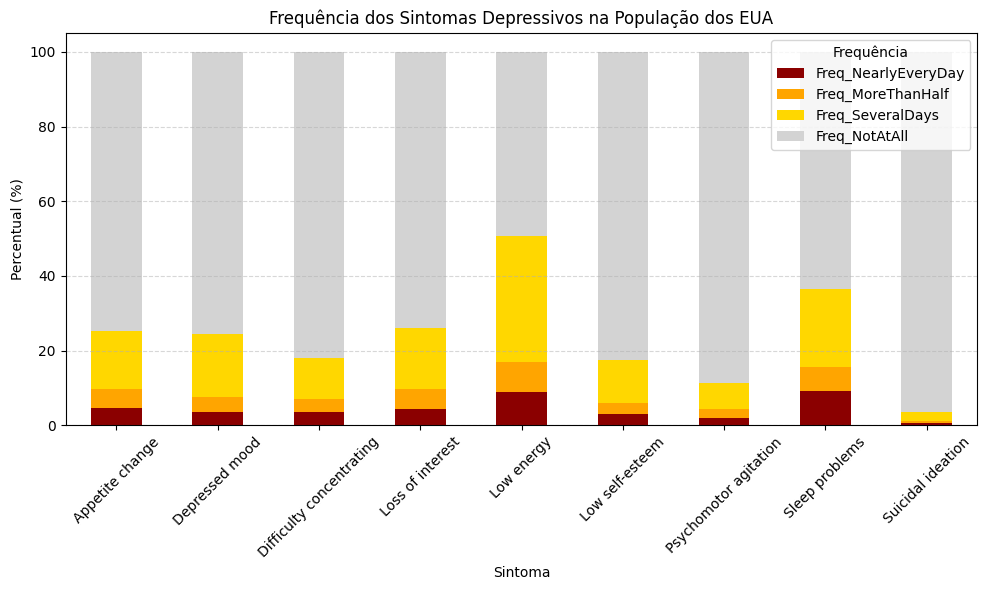

In [37]:
df_sintomas_plot.set_index("Entity")[["Freq_NearlyEveryDay", "Freq_MoreThanHalf", "Freq_SeveralDays", "Freq_NotAtAll"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=["darkred", "orange", "gold", "lightgray"]
)

plt.title("Frequência dos Sintomas Depressivos na População dos EUA")
plt.ylabel("Percentual (%)")
plt.xlabel("Sintoma")
plt.xticks(rotation=45)
plt.legend(title="Frequência")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

**7.	Ver quais sintomas depressivos tem maior impacto geral**

In [38]:
depressive_symptoms_impacto = df_sintomas.withColumn(
    "ImpactoGeral",
    3 * col("Freq_NearlyEveryDay") +
    2 * col("Freq_MoreThanHalf") +
    1 * col("Freq_SeveralDays")
)

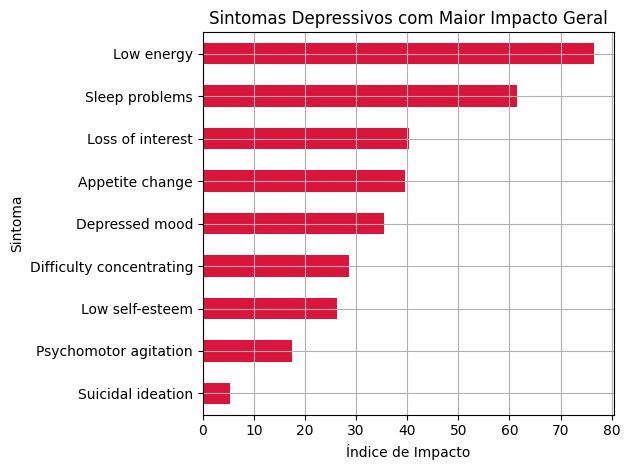

In [39]:
df_impacto_plot = depressive_symptoms_impacto.select("Entity", "ImpactoGeral").orderBy(col("ImpactoGeral").desc()).toPandas()

import matplotlib.pyplot as plt

df_impacto_plot.plot.barh(x="Entity", y="ImpactoGeral", color="crimson", legend=False)
plt.title("Sintomas Depressivos com Maior Impacto Geral")
plt.xlabel("Índice de Impacto")
plt.ylabel("Sintoma")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

**8.	Identificar falhas em países com alta demanda de transtornos mentais e com baixa resposta no tratamento**

In [40]:
anxiety_disorders_treatment_falhas = anxiety_disorders_treatment.select("Entity", "Year", "Untreated") \
                          .orderBy(col("Untreated").desc()) \
                          .limit(10) \
                          .toPandas()

Entity|Code|Year|AdequateTreatment|OtherTreatment|Untreated

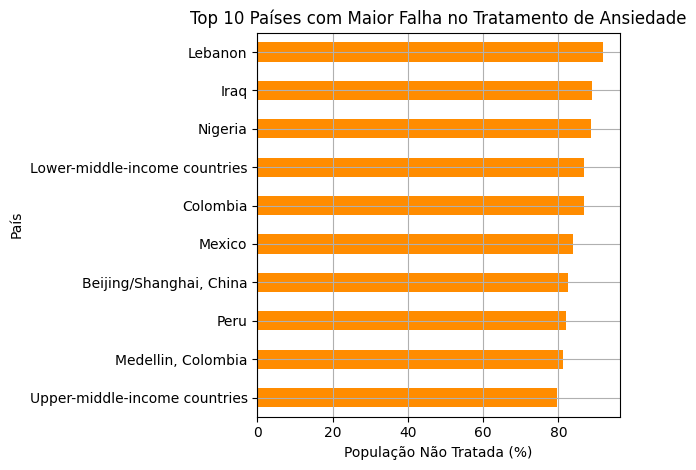

In [41]:
anxiety_disorders_treatment_falhas.plot.barh(x="Entity", y="Untreated", color="darkorange", legend=False)
plt.title("Top 10 Países com Maior Falha no Tratamento de Ansiedade")
plt.xlabel("População Não Tratada (%)")
plt.ylabel("País")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
# Salvar os data sets em cvs "mental_illness_prevalence", "burden_disease" "anxiety_disorders_treatment" e "depressive_symptoms"
mental_illness_prevalence.toPandas().to_csv('mental_illness_prevalence.csv', index=False)
burden_disease.toPandas().to_csv('burden_disease.csv', index=False)
anxiety_disorders_treatment.toPandas().to_csv('anxiety_disorders_treatment.csv', index=False)
depressive_symptoms.toPandas().to_csv('depressive_symptoms.csv', index=False)

In [43]:
from google.colab import files

In [44]:
files.download("mental_illness_prevalence.csv")
files.download("burden_disease.csv")
files.download("anxiety_disorders_treatment.csv")
files.download("depressive_symptoms.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>